--- Starting Feature Engineering: WTI Crude Oil ---
Columns found in dataset: ['date', 'price', 'benchmark']
Calculating WTI Log Returns and 21-Day Volatility...
Generating diagnostic graphs...


C:\Users\siddh\anaconda3\envs\sidd_ds\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


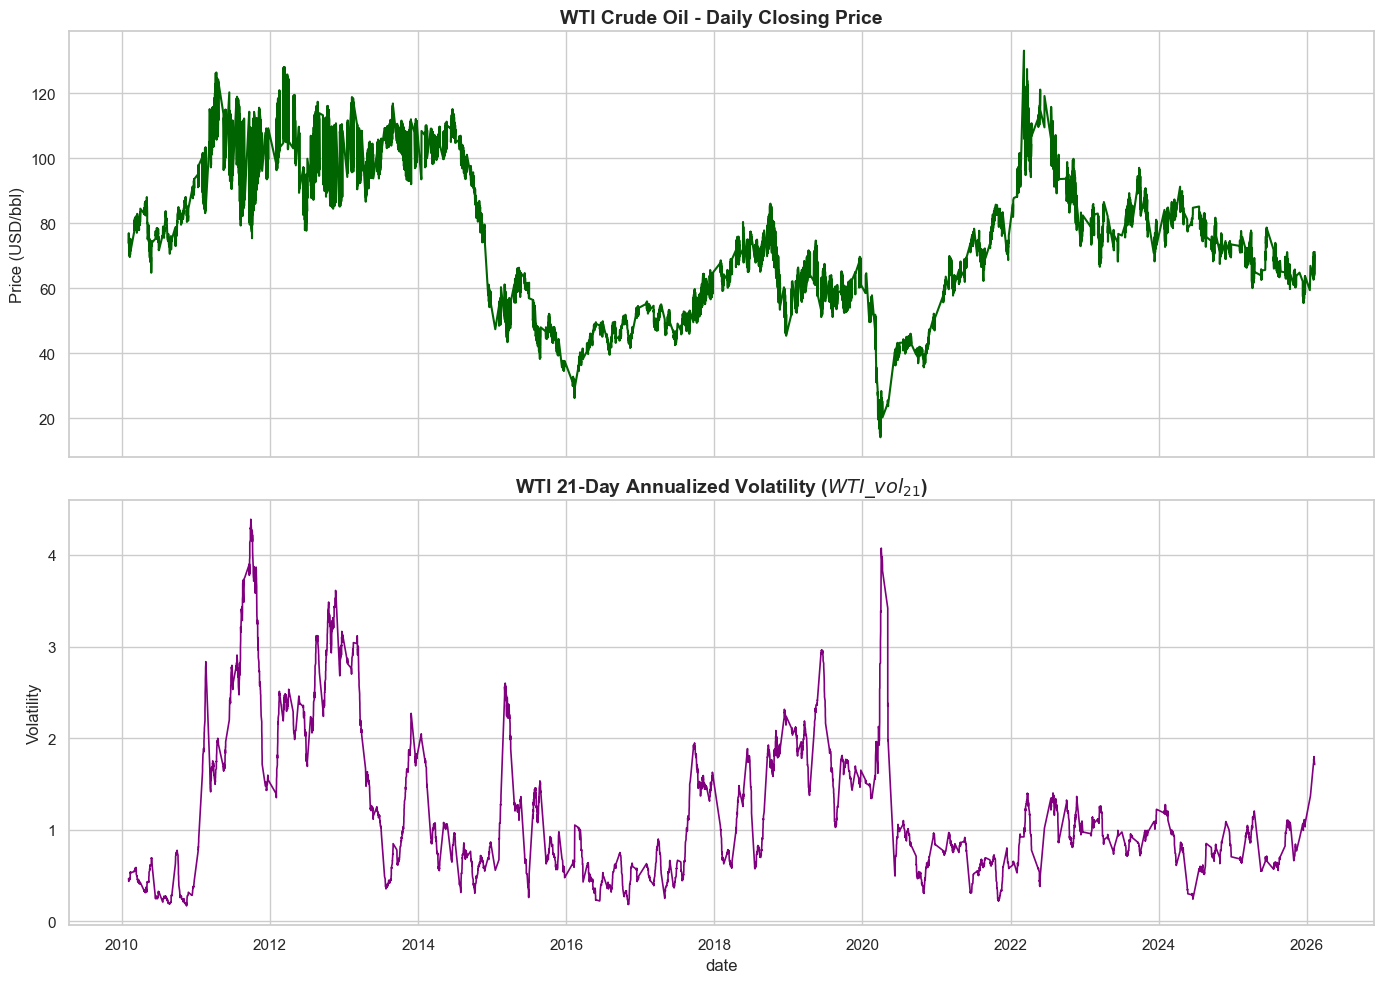


Success! Semi-cleaned WTI dataset saved to: D:\MS_Data_Science_Thesis\Data_Cleaning\Semi_Clean_Datasets\wti_engineered_I.csv
           date  WTI_Close  WTI_Log_Return  WTI_Volatility_21d
8399 2026-02-05      62.90       -0.105090            1.791914
8400 2026-02-06      70.45        0.113357            1.797274
8401 2026-02-06      63.77       -0.099620            1.767122
8402 2026-02-09      64.53        0.011847            1.719188
8403 2026-02-09      71.19        0.098222            1.711083


In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Directory Setup
base_dir = r"D:\MS_Data_Science_Thesis"
raw_folder = os.path.join(base_dir, r"Data_Extraction\Raw_Data_Folder")
clean_folder = os.path.join(base_dir, r"Data_Cleaning\Semi_Clean_Datasets")

os.makedirs(clean_folder, exist_ok=True)

# Update this filename if your raw WTI file is named differently in the Raw_Data_Folder
input_file = os.path.join(raw_folder, "oil_prices_long.csv")

def engineer_wti_features():
    print("--- Starting Feature Engineering: WTI Crude Oil ---")
    
    if not os.path.exists(input_file):
        print(f"Error: Could not find {input_file}")
        return

    # 2. Load Data
    df = pd.read_csv(input_file)
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    print(f"Columns found in dataset: {df.columns.tolist()}")
    
    # Identify the price column
    price_col = 'Close' if 'Close' in df.columns else 'price'
    
    # 3. Complex Feature Generation
    print("Calculating WTI Log Returns and 21-Day Volatility...")
    
    # WTI Daily Log Return
    df['WTI_Log_Return'] = np.log(df[price_col] / df[price_col].shift(1))
    
    # WTI 21-Day Annualized Volatility
    # We multiply by sqrt(252) to annualize the daily volatility, a standard practice in quant finance
    df['WTI_Volatility_21d'] = df['WTI_Log_Return'].rolling(window=21).std() * np.sqrt(252)
    
    # 4. Clean Data
    # Drop the first 21 rows that have NaNs from the rolling calculation
    df_cleaned = df.dropna(subset=['WTI_Volatility_21d']).copy()
    
    # 5. Data Visualization
    print("Generating diagnostic graphs...")
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Plot 1: WTI Price
    ax1.plot(df_cleaned['date'], df_cleaned[price_col], color='darkgreen', linewidth=1.5)
    ax1.set_title('WTI Crude Oil - Daily Closing Price', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (USD/bbl)', fontsize=12)
    
    # Plot 2: WTI Volatility
    ax2.plot(df_cleaned['date'], df_cleaned['WTI_Volatility_21d'], color='purple', linewidth=1.2)
    ax2.set_title(r'WTI 21-Day Annualized Volatility ($WTI\_vol_{21}$)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Volatility', fontsize=12)
    ax2.set_xlabel('date', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # 6. Export the intermediate dataset
    output_path = os.path.join(clean_folder, "wti_engineered_I.csv")
    
    # For the master merge, we only need to carry forward Date, Price, Return, and Volatility
    cols_to_keep = ['date', price_col, 'WTI_Log_Return', 'WTI_Volatility_21d']
    df_export = df_cleaned[cols_to_keep].rename(columns={price_col: 'WTI_Close'})
    
    df_export.to_csv(output_path, index=False)
    
    print(f"\nSuccess! Semi-cleaned WTI dataset saved to: {output_path}")
    print(df_export.tail())

if __name__ == "__main__":
    engineer_wti_features()